In [16]:
### Imports ###
import numpy as np
import matplotlib.pyplot as plt


In [17]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_stochastic_gradient(X, y, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the stochastic gradient descent algorithm where:
    - At each iteration, a single randomly picked example is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch goes through all samples once in random order.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Go through all samples in this epoch
        for i in range(n_samples):
            # Get current sample
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            
            # Compute margin: y_i * (w^T x_i + b)
            margin = y_i * (np.dot(w, x_i) + b)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Update rule: check if point violates margin (margin <= 1)
            if margin <= 1.0:
                # Point violates margin: apply gradient update
                # Gradient w.r.t. w: λw - y_i * x_i (when violating)
                w = w - gamma * (lambda_reg * w - y_i * x_i)
                # Gradient w.r.t. b: -y_i (when violating)
                b = b - gamma * (-y_i)
            else:
                # Point satisfies margin: only update w with regularization term
                w = w - gamma * (lambda_reg * w)
                # b doesn't change when margin is satisfied
            
            # Increase μ after each iteration (decreases learning rate)
            mu += mu_increment
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}")
    
    return w, b, history

def SVM_minibatch_gradient(X, y, batch_size=10, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Mini-batch Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the mini-batch stochastic gradient descent algorithm where:
    - At each iteration, a mini-batch of M randomly picked examples is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch, then divided into mini-batches
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    batch_size : int, optional
        Size of each mini-batch M (default: 10).
        The dataset is divided into mini-batches of this size.
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch processes all samples once through mini-batches.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Compute number of batches per epoch
    n_batches = (n_samples + batch_size - 1) // batch_size  # Ceiling division
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Process data in mini-batches
        for batch_idx in range(n_batches):
            # Get batch indices
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)
            batch_indices = np.arange(start_idx, end_idx)
            
            # Get batch data
            X_batch = X_shuffled[batch_indices]
            y_batch = y_shuffled[batch_indices]
            batch_size_actual = len(batch_indices)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Accumulate gradients over the mini-batch
            grad_w_sum = np.zeros(n_features)
            grad_b_sum = 0.0
            
            # Compute gradients for each sample in the batch
            for i in range(batch_size_actual):
                x_i = X_batch[i]
                y_i = y_batch[i]
                
                # Compute margin: y_i * (w^T x_i + b)
                margin = y_i * (np.dot(w, x_i) + b)
                
                # Update rule: check if point violates margin (margin <= 1)
                if margin <= 1.0:
                    # Point violates margin: contribute to gradient
                    # Gradient w.r.t. w: -y_i * x_i (when violating)
                    grad_w_sum += -y_i * x_i
                    # Gradient w.r.t. b: -y_i (when violating)
                    grad_b_sum += -y_i
            
            # Update parameters: add regularization term for w, then apply gradient step
            # For w: λw + (1/M) * Σ grad_w
            w = w - gamma * (lambda_reg * w + grad_w_sum / batch_size_actual)
            # For b: (1/M) * Σ grad_b
            b = b - gamma * (grad_b_sum / batch_size_actual)
            
            # Increase μ after each iteration (decreases learning rate)
            mu += mu_increment
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}, Batch size = {batch_size}")
    
    return w, b, history



In [18]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax



In [19]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]


Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


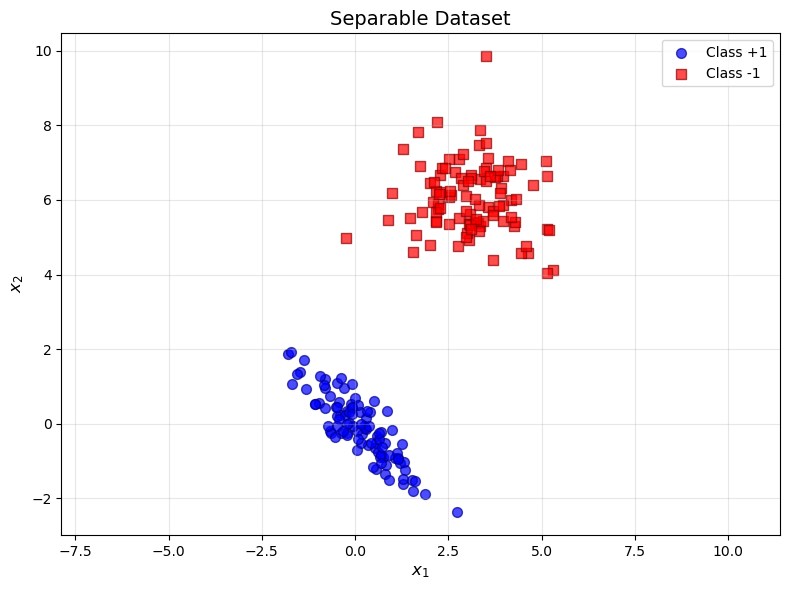

In [20]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

Training SVM using Stochastic Gradient Descent...
Parameters: λ = 0.0001, max_epochs = 50, μ_init = 100, μ_increment = 0.1

Epoch 10/50: Loss = 0.560565, ||w||^2 = 0.280002
Epoch 20/50: Loss = 0.253462, ||w||^2 = 0.303084
Epoch 30/50: Loss = 0.139130, ||w||^2 = 0.338471
Epoch 40/50: Loss = 0.088117, ||w||^2 = 0.354580
Epoch 50/50: Loss = 0.065601, ||w||^2 = 0.363601

Final solution:
w = [-0.3101445  -0.51711881]
b = 1.4873546100063408
Final loss = 0.065601
Final ||w||^2 = 0.363601


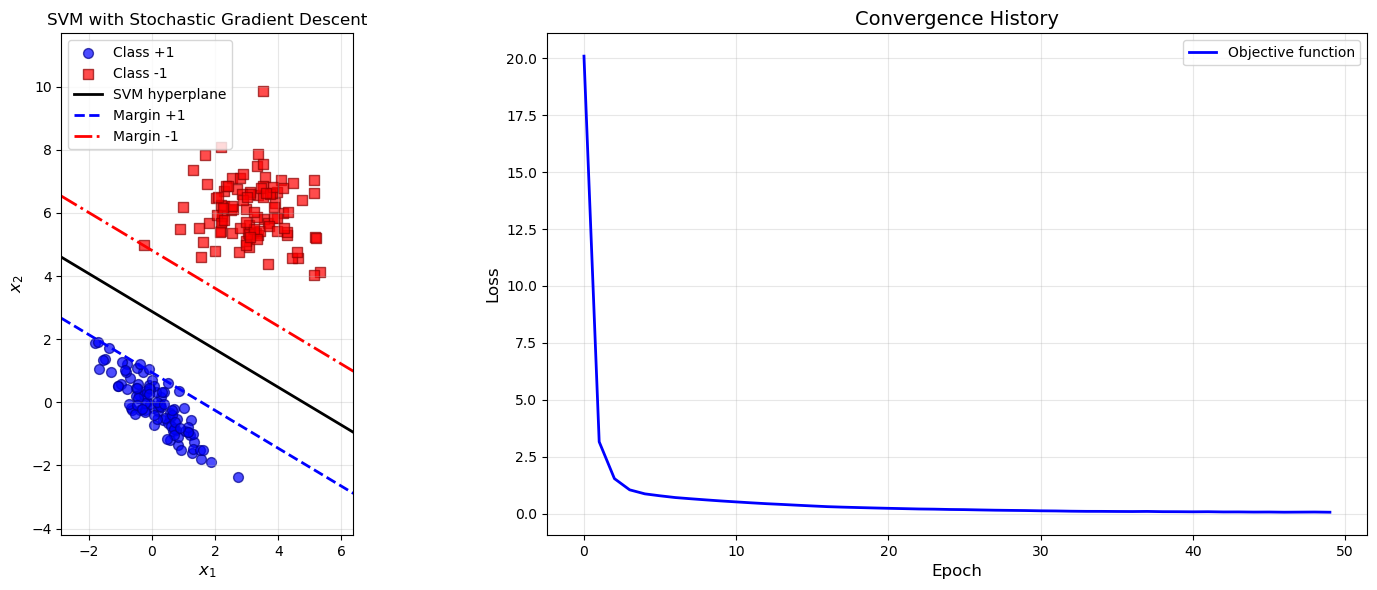

In [21]:
### Exercise 1 ###

# Apply Stochastic Gradient Descent SVM to the separable dataset

# Set parameters for stochastic gradient descent
lambda_reg = 1e-4  # Small regularization parameter
max_epochs = 50    # Number of epochs
mu_init = 100      # Initial μ value for learning rate computation
mu_increment = 0.1 # Increment for μ after each iteration

print("Training SVM using Stochastic Gradient Descent...")
print(f"Parameters: λ = {lambda_reg}, max_epochs = {max_epochs}, μ_init = {mu_init}, μ_increment = {mu_increment}\n")

# Train the SVM
w_sgd, b_sgd, history = SVM_stochastic_gradient(
    X_sep, y_sep, 
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)

print(f"\nFinal solution:")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history['w_norm'][-1]:.6f}")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: SVM decision boundary with margins
plot_svm_with_margin(X_sep, y_sep, w_sgd, b_sgd, ax=axes[0], title="SVM with Stochastic Gradient Descent")

# Plot 2: Convergence history
axes[1].plot(history['loss'], 'b-', linewidth=2, label='Objective function')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Convergence History', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Dataset created with 200 samples for mini-batch experiments
Class +1: 100 samples
Class -1: 100 samples

Training with Stochastic Gradient Descent (batch size = 1)
Epoch 10/50: Loss = 0.560565, ||w||^2 = 0.280002
Epoch 20/50: Loss = 0.253462, ||w||^2 = 0.303084
Epoch 30/50: Loss = 0.139130, ||w||^2 = 0.338471
Epoch 40/50: Loss = 0.088117, ||w||^2 = 0.354580
Epoch 50/50: Loss = 0.065601, ||w||^2 = 0.363601

Final solution (Stochastic):
w = [-0.3101445  -0.51711881]
b = 1.4873546100063408
Final loss = 0.065601
Final ||w||^2 = 0.363601

Training with Mini-batch Gradient Descent (batch size = 10)
Epoch 10/50: Loss = 19.616011, ||w||^2 = 0.122752, Batch size = 10
Epoch 20/50: Loss = 3.085600, ||w||^2 = 0.169012, Batch size = 10
Epoch 30/50: Loss = 1.451902, ||w||^2 = 0.207030, Batch size = 10
Epoch 40/50: Loss = 1.113417, ||w||^2 = 0.224690, Batch size = 10
Epoch 50/50: Loss = 0.907122, ||w||^2 = 0.242458, Batch size = 10

Final solution (Batch size = 10):
w = [-0.29984265 -0.39057952]
b = 

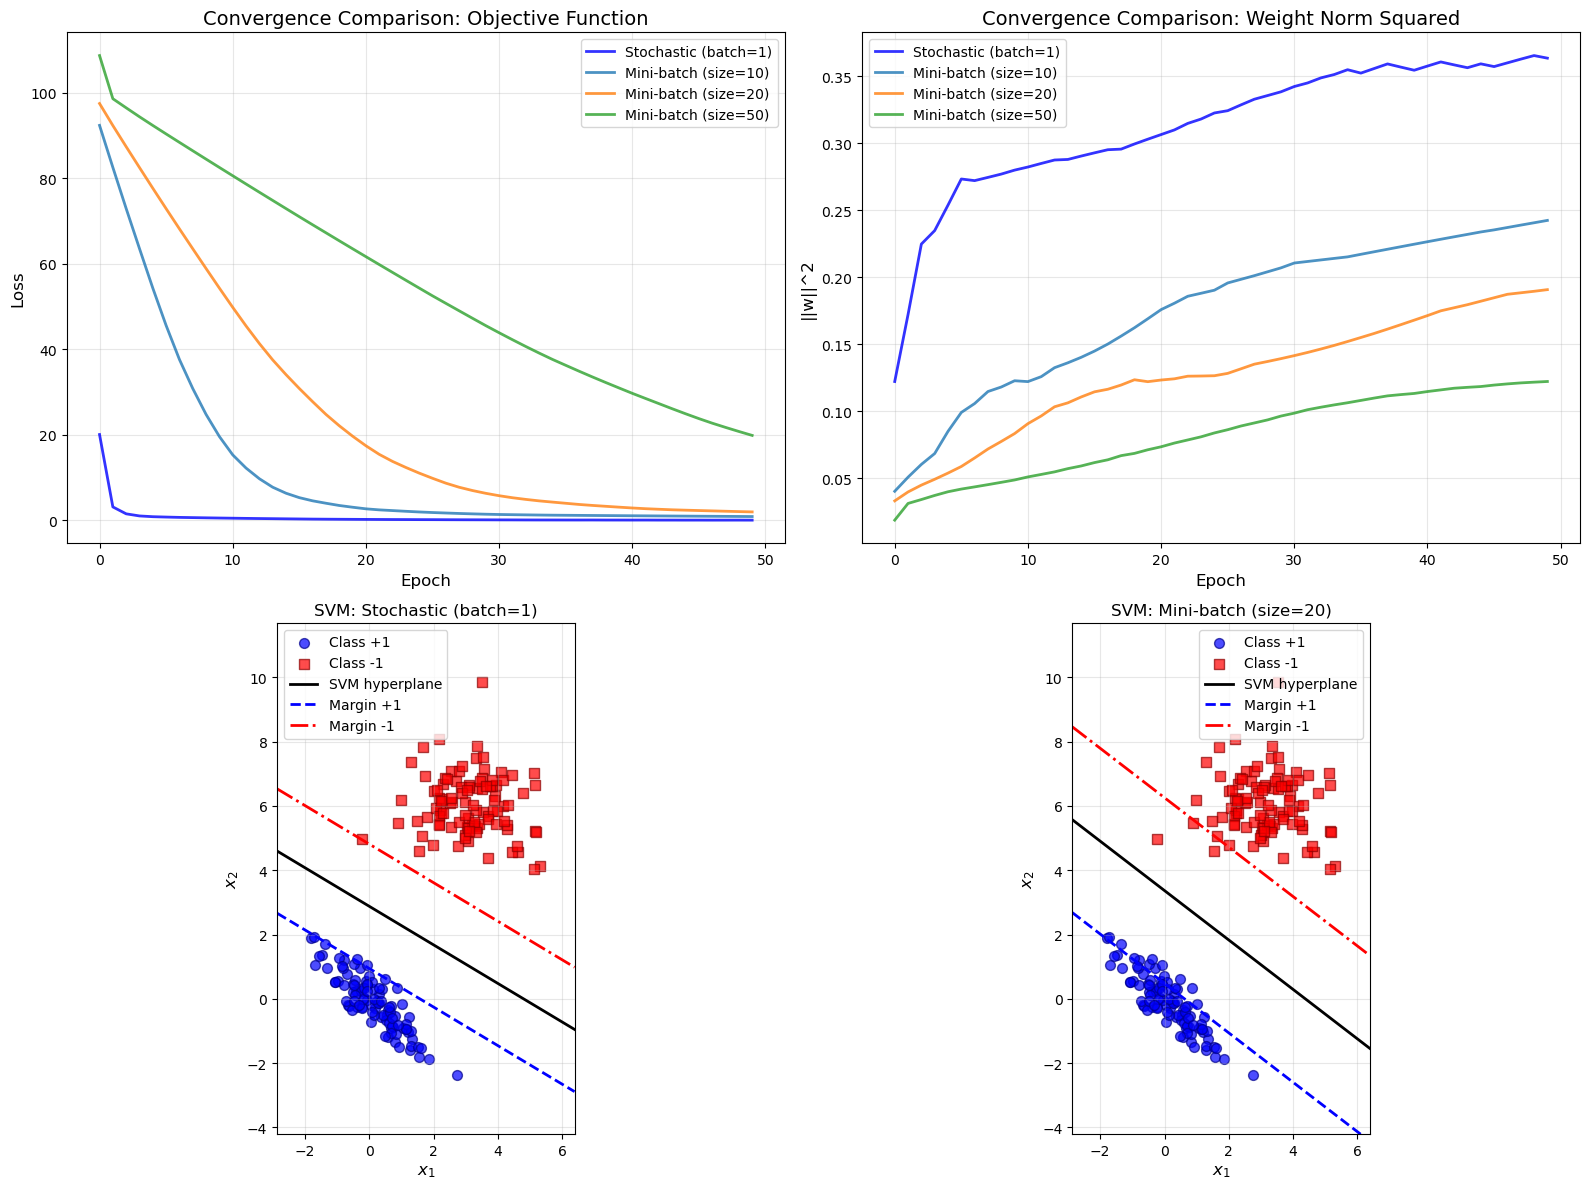

SUMMARY COMPARISON
Method                    Final Loss      Final ||w||^2  
--------------------------------------------------------------------------------
Stochastic (batch=1)      0.065601        0.363601       
Mini-batch (size=10)      0.907122        0.242458       
Mini-batch (size=20)      1.993181        0.190775       
Mini-batch (size=50)      19.883105       0.122194       


In [22]:
### Exercise 2 ###

# Mini-batch Stochastic Gradient Descent Experiments

# Create a dataset with 200 samples (100 per class) for comparison
X_batch, y_batch = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Dataset created with {len(y_batch)} samples for mini-batch experiments")
print(f"Class +1: {np.sum(y_batch == 1)} samples")
print(f"Class -1: {np.sum(y_batch == -1)} samples\n")

# Set parameters for experiments
lambda_reg = 1e-4
max_epochs = 50
mu_init = 100
mu_increment = 0.1

# Mini-batch sizes to test
batch_sizes = [10, 20, 50]

# Store results for comparison
results = {}

print("=" * 80)
print("Training with Stochastic Gradient Descent (batch size = 1)")
print("=" * 80)
w_sgd, b_sgd, history_sgd = SVM_stochastic_gradient(
    X_batch, y_batch,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)
results['stochastic'] = {'w': w_sgd, 'b': b_sgd, 'history': history_sgd, 'label': 'Stochastic (batch=1)'}

print(f"\nFinal solution (Stochastic):")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history_sgd['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history_sgd['w_norm'][-1]:.6f}\n")

# Test different mini-batch sizes
for batch_size in batch_sizes:
    print("=" * 80)
    print(f"Training with Mini-batch Gradient Descent (batch size = {batch_size})")
    print("=" * 80)
    w_mb, b_mb, history_mb = SVM_minibatch_gradient(
        X_batch, y_batch,
        batch_size=batch_size,
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=True
    )
    results[f'batch_{batch_size}'] = {
        'w': w_mb, 
        'b': b_mb, 
        'history': history_mb, 
        'label': f'Mini-batch (size={batch_size})'
    }
    
    print(f"\nFinal solution (Batch size = {batch_size}):")
    print(f"w = {w_mb}")
    print(f"b = {b_mb}")
    print(f"Final loss = {history_mb['loss'][-1]:.6f}")
    print(f"Final ||w||^2 = {history_mb['w_norm'][-1]:.6f}\n")

# Visualize results: Convergence comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Convergence history - Loss
axes[0, 0].plot(results['stochastic']['history']['loss'], 'b-', linewidth=2, 
                label=results['stochastic']['label'], alpha=0.8)
for batch_size in batch_sizes:
    key = f'batch_{batch_size}'
    axes[0, 0].plot(results[key]['history']['loss'], linewidth=2, 
                    label=results[key]['label'], alpha=0.8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Convergence Comparison: Objective Function', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Convergence history - Weight norm
axes[0, 1].plot(results['stochastic']['history']['w_norm'], 'b-', linewidth=2, 
                label=results['stochastic']['label'], alpha=0.8)
for batch_size in batch_sizes:
    key = f'batch_{batch_size}'
    axes[0, 1].plot(results[key]['history']['w_norm'], linewidth=2, 
                    label=results[key]['label'], alpha=0.8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('||w||^2', fontsize=12)
axes[0, 1].set_title('Convergence Comparison: Weight Norm Squared', fontsize=14)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Final decision boundaries comparison - Stochastic
plot_svm_with_margin(X_batch, y_batch, results['stochastic']['w'], results['stochastic']['b'], 
                     ax=axes[1, 0], title=f"SVM: {results['stochastic']['label']}")

# Plot 4: Final decision boundaries comparison - Best mini-batch (batch size = 20)
plot_svm_with_margin(X_batch, y_batch, results['batch_20']['w'], results['batch_20']['b'], 
                     ax=axes[1, 1], title=f"SVM: {results['batch_20']['label']}")

plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 80)
print("SUMMARY COMPARISON")
print("=" * 80)
print(f"{'Method':<25} {'Final Loss':<15} {'Final ||w||^2':<15}")
print("-" * 80)
for key, result in results.items():
    final_loss = result['history']['loss'][-1]
    final_w_norm = result['history']['w_norm'][-1]
    print(f"{result['label']:<25} {final_loss:<15.6f} {final_w_norm:<15.6f}")
print("=" * 80)



Dataset created with 200 samples for comparison
Class +1: 100 samples
Class -1: 100 samples

Training with Stochastic Gradient Descent (batch size = 1)
Training with Mini-batch Gradient Descent (batch size = 20)
Training with Gradient Descent (batch size = n_samples)

Training completed!



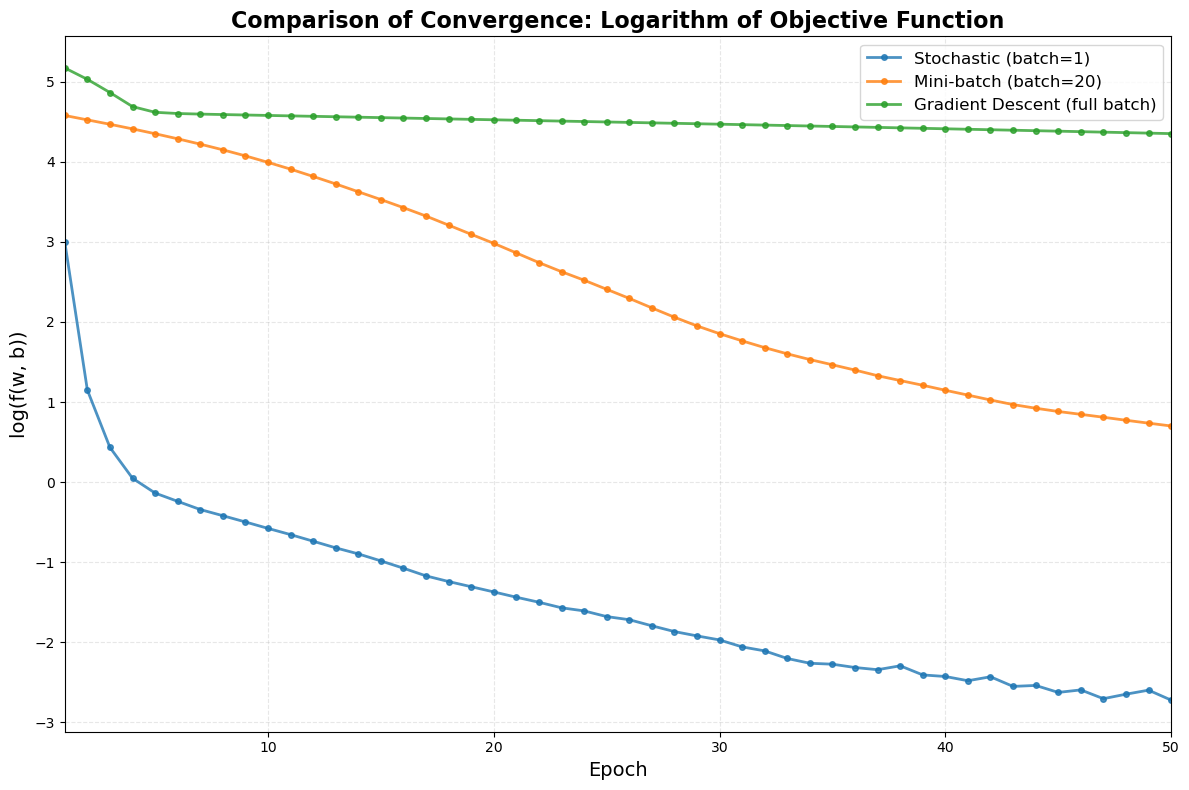

SUMMARY COMPARISON - Final Objective Values
Method                              Final log(f(w,b))    Final f(w,b)        
--------------------------------------------------------------------------------
Stochastic (batch=1)                -2.724163            0.065601            
Mini-batch (batch=20)               0.700597             2.014954            
Gradient Descent (full batch)       4.353228             77.728940           


In [23]:
### Exercise 3 ###

# : Comparison of Stochastic, Mini-batch, and Gradient Descent ###

# Create a dataset with 200 samples (100 per class) for comparison
X_compare, y_compare = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
n_samples = len(y_compare)

print(f"Dataset created with {n_samples} samples for comparison")
print(f"Class +1: {np.sum(y_compare == 1)} samples")
print(f"Class -1: {np.sum(y_compare == -1)} samples\n")

# Set parameters for experiments
lambda_reg = 1e-4
max_epochs = 50
mu_init = 100
mu_increment = 0.1

# Store results for comparison
results_compare = {}

print("=" * 80)
print("Training with Stochastic Gradient Descent (batch size = 1)")
print("=" * 80)
w_sgd_comp, b_sgd_comp, history_sgd_comp = SVM_stochastic_gradient(
    X_compare, y_compare,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Stochastic (batch=1)'] = history_sgd_comp

print("=" * 80)
print("Training with Mini-batch Gradient Descent (batch size = 20)")
print("=" * 80)
w_mb_comp, b_mb_comp, history_mb_comp = SVM_minibatch_gradient(
    X_compare, y_compare,
    batch_size=20,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Mini-batch (batch=20)'] = history_mb_comp

print("=" * 80)
print("Training with Gradient Descent (batch size = n_samples)")
print("=" * 80)
# Gradient descent is equivalent to mini-batch with batch_size = n_samples
w_gd_comp, b_gd_comp, history_gd_comp = SVM_minibatch_gradient(
    X_compare, y_compare,
    batch_size=n_samples,  # Full batch = gradient descent
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)
results_compare['Gradient Descent (full batch)'] = history_gd_comp

print("\nTraining completed!\n")

# Create the comparison plot: logarithm of f(w, b) vs epoch
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot log of objective function for each method
epochs = np.arange(1, max_epochs + 1)

for method_name, history in results_compare.items():
    # Compute log of loss, handling potential zeros or very small values
    log_loss = np.log(np.maximum(history['loss'], 1e-10))
    ax.plot(epochs, log_loss, linewidth=2, label=method_name, marker='o', markersize=4, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('log(f(w, b))', fontsize=14)
ax.set_title('Comparison of Convergence: Logarithm of Objective Function', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(1, max_epochs)

plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 80)
print("SUMMARY COMPARISON - Final Objective Values")
print("=" * 80)
print(f"{'Method':<35} {'Final log(f(w,b))':<20} {'Final f(w,b)':<20}")
print("-" * 80)
for method_name, history in results_compare.items():
    final_loss = history['loss'][-1]
    final_log_loss = np.log(np.maximum(final_loss, 1e-10))
    print(f"{method_name:<35} {final_log_loss:<20.6f} {final_loss:<20.6f}")
print("=" * 80)

